In [1]:
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

import time
import gc
import math

import torch
import torch.optim as optim
import torch.nn as nn
import torch.nn.functional as F
from torch.nn.utils import clip_grad_norm_
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torch.utils.tensorboard import SummaryWriter
import torchvision.transforms.functional as VF
from torch.autograd.graph import saved_tensors_hooks

import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

from torch_utils import gpu_utils
from torch_utils import cuda_utils
from torch_utils import training_utils

In [2]:
device = 'cuda'
print(f"PyTorch version: {torch.__version__}")

PyTorch version: 2.8.0+cu128


In [3]:
def calculate_training_memory(model, dataset, criterion, batch_size=4, device="cuda"):
    model.to(device)
    model.zero_grad()
    model.train()

    total_params=sum(p.numel() for p in model.parameters() if p.requires_grad)
    
    dataLoader = DataLoader(
        dataset=dataset,
        batch_size=batch_size)

    input, target = next(iter(dataLoader))
    input, target = input.to(device), target.to(device)

    seen_ptrs = set([p.data_ptr() for p in model.parameters()]) # To avoid storing model parameters
    saved = []

    def pack_hook(t):
        # Runs during forward when autograd saves a tensor
        tensor_dict = {
            "shape": t.shape,
            "dtype": t.dtype,
            "device": t.device,
            "requires_grad": t.requires_grad,
            "numel": t.numel(),
            "element_size": t.element_size(),
            "memory" : t.numel() * t.element_size(),
            "data_ptr": t.data_ptr()
        }
        if not t.data_ptr() in seen_ptrs:
            saved.append(tensor_dict)
            seen_ptrs.add(t.data_ptr())
        return t

    def unpack_hook(t):
        # Runs during backward when autograd unpacks it
        return t

    with saved_tensors_hooks(pack_hook, unpack_hook):
        logits = model(input)
        loss = criterion(logits, target)
        loss.backward()

    activation_memory = sum(s["memory"] for s in saved)
    result = {
        "number_of_params": total_params,
        "memory_activations_per_example": activation_memory / batch_size,
        "memory_params": total_params * 4,
        "memory_grad": total_params * 4,
        "memory_adam": total_params * 8,
        "memory_total": activation_memory + total_params * 16,
        "unit": "B"
    }
    return result

In [4]:
transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset = datasets.MNIST(
    root="./DATA",
    train=True,
    download=True,
    transform=transform)

valid_dataset = datasets.MNIST(
    root="./DATA",
    train=False,
    download=True,
    transform=transforms.ToTensor())    

100.0%
100.0%
100.0%
100.0%


In [5]:
class SimpleNN(nn.Module):
    def __init__(self):
        super(SimpleNN, self).__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28 * 28, 1024)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(1024, 128)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.relu1(x)
        x = self.fc2(x)
        x = self.relu2(x)
        x = self.fc3(x)        
        return x

In [6]:
model = SimpleNN().to(device)
optimizer = optim.AdamW(
    params=model.parameters(),
    lr=0.001,
    weight_decay=0.01
)
criterion = nn.CrossEntropyLoss()
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50, eta_min=1e-5)

In [7]:
max_batch_size = training_utils.find_max_train_batch(
    model = model,
    dataset = train_dataset,
    optimizer = optimizer,
    criterion = criterion,
    device = device,
    verbose = True)

Current batch = 30000 Result: True
Current batch = 45000 Result: True
Current batch = 52500 Result: True
Current batch = 56250 Result: True
Current batch = 58125 Result: True
Current batch = 59062 Result: True
Current batch = 59531 Result: True
Current batch = 59765 Result: True
Current batch = 59882 Result: True
Current batch = 59941 Result: True
Current batch = 59970 Result: True
Current batch = 59985 Result: True
Current batch = 59992 Result: True
Current batch = 59996 Result: True
Current batch = 59998 Result: True
Current batch = 59999 Result: True


In [8]:
batch_size_to_test = [1, 16, 64, 128, 256, 512, 1024, 1536, 2048, 3072, 4096, 6144, 8192]
throughput_results = {
    x:training_utils.calculate_throughput(
        model = model,
        dataset = train_dataset,
        optimizer = optimizer,
        criterion = criterion,
        batch_size = x,
        device = 'cuda', 
        max_time_s = 2) for x in batch_size_to_test
}

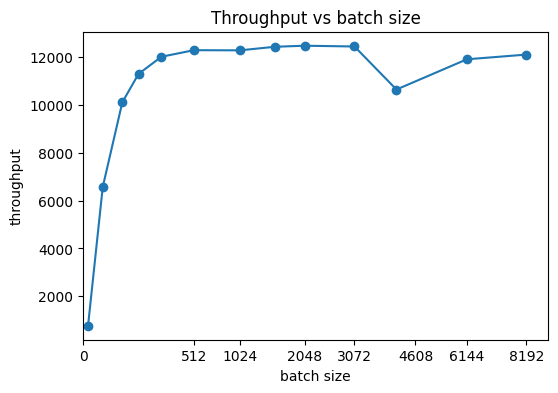

In [9]:
n_ticks = 8
x_ticks = sorted(list(set([math.floor(((x * (max(batch_size_to_test) ** 0.5) / n_ticks)**2)/512)*512 for x in range(n_ticks+1)])))
x = list(throughput_results.keys())
y = list(throughput_results.values())
plt.figure(figsize=(6,4))
plt.plot(x, y, marker='o', linestyle='-')
plt.xscale('function', functions=(lambda x: x**0.5, lambda x: x**2))
plt.xticks(x_ticks)
plt.xlabel('batch size')
plt.ylabel('throughput')
plt.title('Throughput vs batch size')
plt.show()